<a href="https://colab.research.google.com/github/hashnadeem/Predictive_Linear_Regression_CaliforniaDataset/blob/main/Predictive_Linear_Regression_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Linear Regression Model Pipeline

## Objective
Build a supervised machine learning pipeline using the California Housing dataset.

## Tasks
- Load dataset
- Data exploration
- Data preprocessing
- Feature scaling
- Missing value imputation
- Train Linear/Ridge Regression model
- Evaluate using RMSE and R² Score

Dataset: California Housing (Scikit-Learn)

**Loading and Understanding Dataset**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [2]:
housing = fetch_california_housing()
print(housing.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [3]:
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["MedHouseVal"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("Shape of dataset:", df.shape)

Shape of dataset: (20640, 9)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


**Exploratory Data Analysis (EDA)**

In [7]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


**Visualize Feature Distributions**

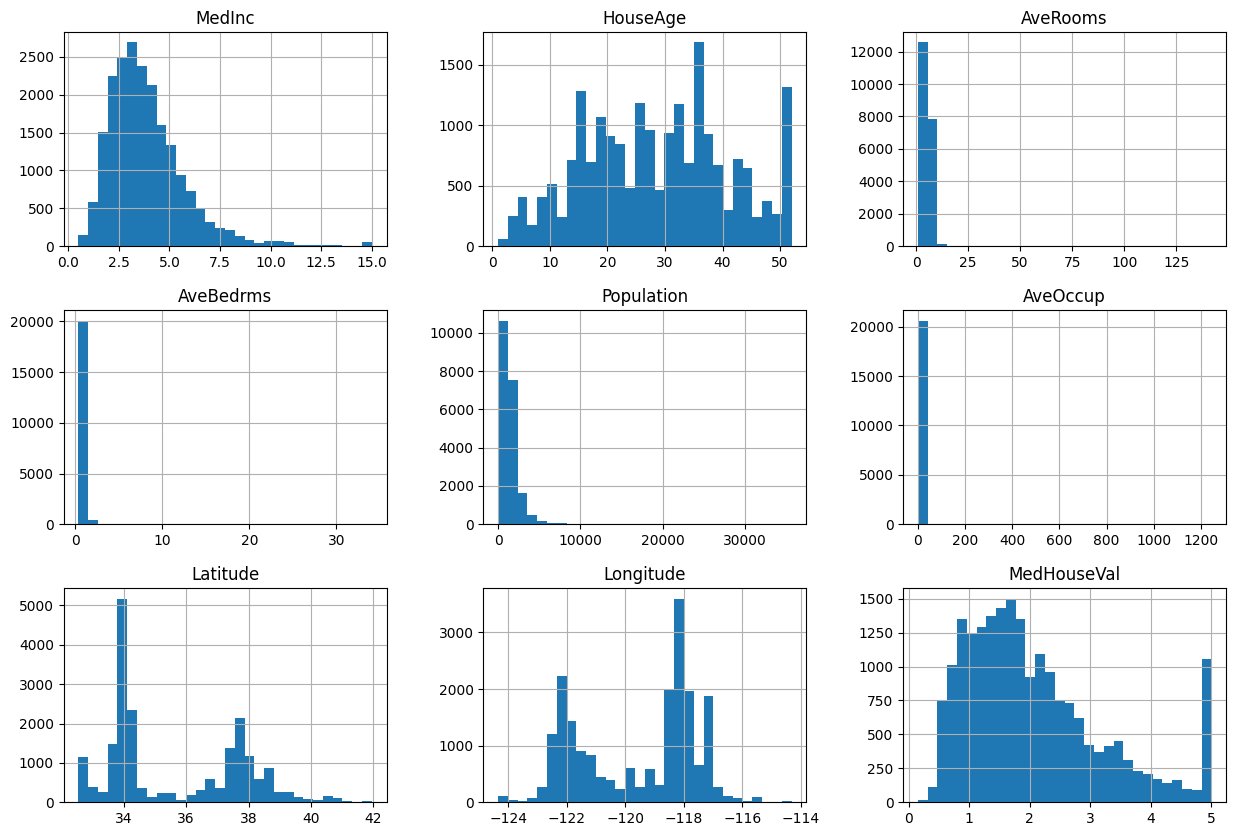

In [9]:
df.hist(figsize=(15,10), bins=30)
plt.show()

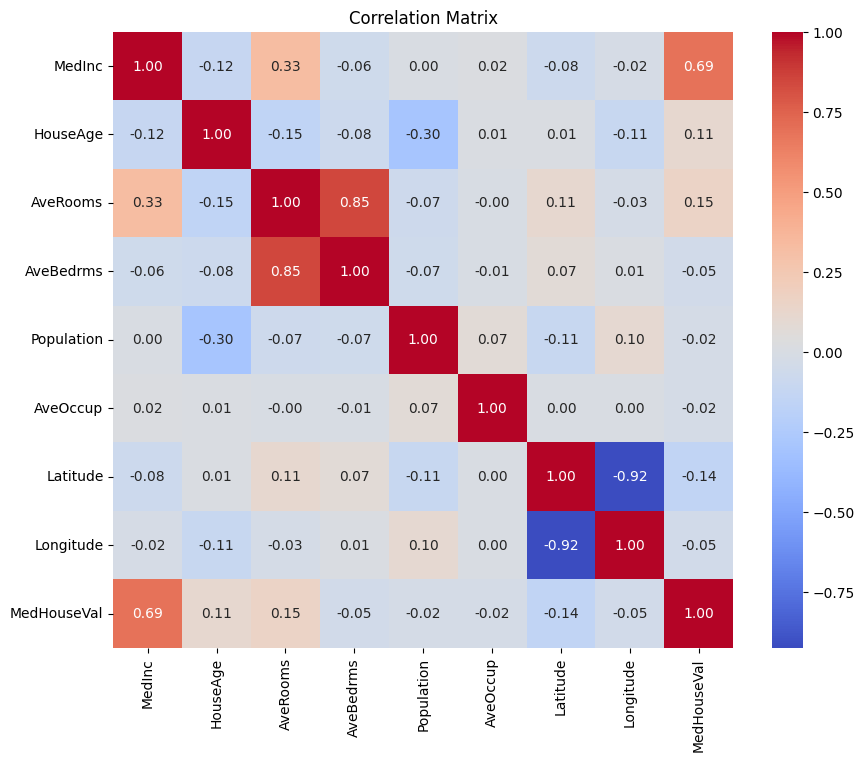

In [10]:
correlation_matrix = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [11]:
correlation_matrix["MedHouseVal"].sort_values(ascending=False)

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


## Exploratory Data Analysis (EDA)

### Observations

- The dataset contains no missing values.
- No duplicate records were found.
- All features are numerical.
- Median Income (MedInc) has the strongest positive correlation with house value.
- Some features show weak or negative correlations.
- Feature scaling will still be necessary because variables have different ranges.

**Data Preprocessing Pipeline**

In [12]:

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


**Train-Test Split**

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

Training Features: (16512, 8)
Testing Features: (4128, 8)


In [21]:

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

Categorical Features:
Index([], dtype='object')


In [22]:

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)

In [23]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [24]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [25]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(16512, 8)
(4128, 8)


## Data Preprocessing

The preprocessing pipeline includes:

- Mean Imputation for numerical features
- Most Frequent Imputation for categorical features
- One-Hot Encoding for categorical variables
- Standard Feature Scaling
- ColumnTransformer for unified preprocessing

Although the California Housing dataset contains only numerical attributes, the pipeline is designed to handle categorical data for future datasets.

**Build and Train the Models**

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

In [27]:

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [28]:
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [29]:
linear_predictions = linear_model.predict(X_test)

print(linear_predictions[:5])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


**Ridge Regression**

In [30]:

ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=1.0))
    ]
)

In [31]:

ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully!")

Ridge Regression model trained successfully!


In [32]:
ridge_predictions = ridge_model.predict(X_test)

print(ridge_predictions[:5])

[0.71947224 1.76384666 2.709309   2.83875678 2.60417736]


## Model Training

Two regression models were trained:

### Linear Regression
- Basic regression model
- Learns a linear relationship between features and target

### Ridge Regression
- Regularized version of Linear Regression
- Helps reduce overfitting
- Uses L2 Regularization
- Alpha value = 1.0

**Evaluation Metrics**

In [33]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

In [34]:
linear_r2 = r2_score(y_test, linear_predictions)
linear_rmse = root_mean_squared_error(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("R² Score :", linear_r2)
print("RMSE     :", linear_rmse)

Linear Regression Results
-------------------------
R² Score : 0.575787706032451
RMSE     : 0.7455813830127763


In [36]:
ridge_r2 = r2_score(y_test, ridge_predictions)
ridge_rmse = root_mean_squared_error(y_test, ridge_predictions)

print("Ridge Regression Results")
print("------------------------")
print("R² Score :", ridge_r2)
print("RMSE     :", ridge_rmse)

Ridge Regression Results
------------------------
R² Score : 0.5758157428913684
RMSE     : 0.7455567442814779


In [37]:

results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "R2 Score": [linear_r2, ridge_r2],
    "RMSE": [linear_rmse, ridge_rmse]
})

results

,Model,R2 Score,RMSE
0,Linear Regression,0.575788,0.745581
1,Ridge Regression,0.575816,0.745557


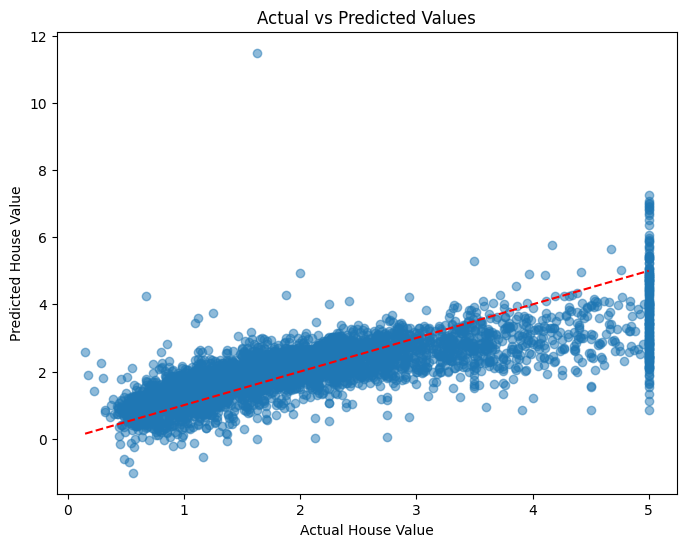

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    ridge_predictions,
    alpha=0.5
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted Values")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

## Model Evaluation

The models were evaluated using:

### R² Score
Measures how much variance in the target variable is explained by the model.

- Higher is better
- Maximum value is 1

### RMSE
Measures the average prediction error.

- Lower is better

### Results

Both Linear Regression and Ridge Regression achieved similar performance. Ridge Regression slightly improves generalization by applying L2 regularization.